In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns
df = pd.read_csv("/Users/athipongjindaphram/Documents/Python For Data Analyst/data_jobs.csv")
#Cleaning Date Column -> Type : Date time
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
df_us = df[df["job_country"] == "United States"].dropna(subset="salary_year_avg").copy()


In [21]:
job_titles = df_us["job_title_short"].value_counts().index[:6].tolist()

In [22]:
df_us_top6 = df_us[
    df_us["job_title_short"]
    .isin(job_titles)
    ]

In [23]:
job_order = df_us_top6.groupby("job_title_short")["salary_year_avg"].median().sort_values(ascending=False).index

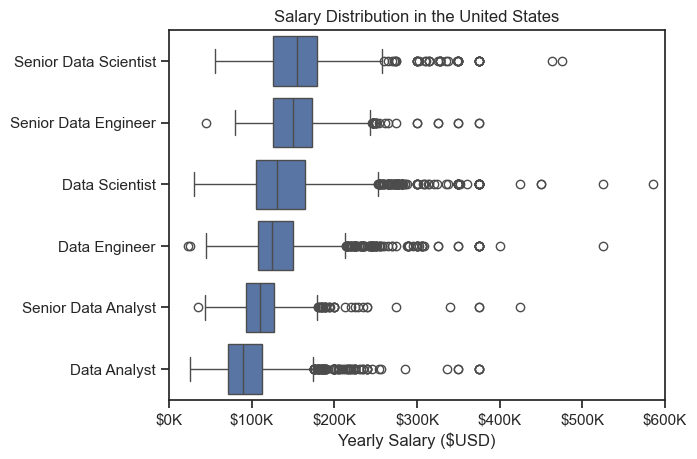

In [25]:
sns.boxplot(data=df_us_top6, x="salary_year_avg", y="job_title_short", order=job_order)
sns.set_theme(style="ticks")

plt.title("Salary Distribution in the United States")
plt.xlabel("Yearly Salary ($USD)")
plt.ylabel("")
plt.xlim(0,600000)

ticks_x = plt.FuncFormatter(lambda y, pos: f"${int(y/1000)}K")
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

In [28]:
df_da_us = df[
    (df["job_title_short"] == "Data Analyst")
    & 
    (df["job_country"] == "United States")
    ].copy()

In [29]:
df_da_us = df_da_us.explode("job_skills")

In [39]:
df_da_top_pay = df_da_us.groupby("job_skills")["salary_year_avg"].agg(["count", "median"]).sort_values(by="median", ascending=False)
df_da_top_pay = df_da_top_pay.head(10)
df_da_top_pay

,count,median
job_skills,,
dplyr,2,196250.0
bitbucket,3,189000.0
gitlab,3,186000.0
solidity,1,179000.0
hugging face,1,175000.0
couchbase,1,160515.0
ansible,1,159640.0
mxnet,2,149000.0
cassandra,6,148250.0


In [38]:
df_da_skills = df_da_us.groupby("job_skills")["salary_year_avg"].agg(["count", "median"]).sort_values(by="count", ascending=False)
df_da_skills = df_da_skills.head(10).sort_values(by="median", ascending=False)
df_da_skills

,count,median
job_skills,,
python,1431,97500.00
tableau,1364,92875.00
r,893,92500.00
sql server,286,92500.00
sql,2508,91000.00
sas,926,90000.00
power bi,838,90000.00
powerpoint,462,85000.00
excel,1808,84392.00


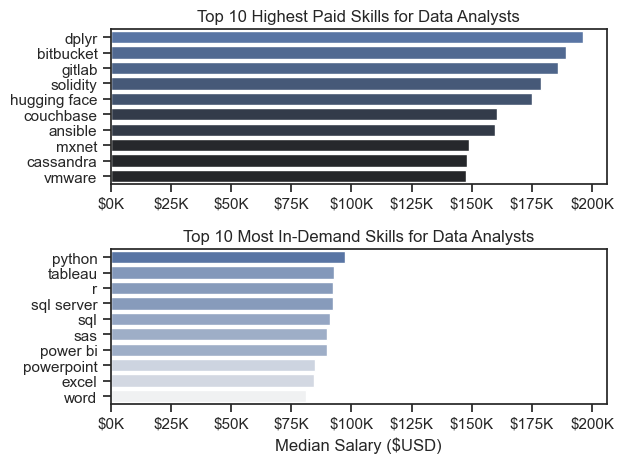

In [47]:
fig, ax = plt.subplots(2,1)

sns.set_theme(style="ticks")

sns.barplot(data=df_da_top_pay, x="median", y=df_da_top_pay.index, hue="median", ax=ax[0], palette="dark:b")
ax[0].legend().remove()
ax[0].set_title("Top 10 Highest Paid Skills for Data Analysts")
ax[0].set_ylabel("")
ax[0].set_xlabel("")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))

sns.barplot(data=df_da_skills, x="median", y=df_da_skills.index, hue="median", ax=ax[1], palette="light:b")
ax[1].legend().remove()

ax[1].set_title("Top 10 Most In-Demand Skills for Data Analysts")
ax[1].set_ylabel("")
ax[1].set_xlabel("Median Salary ($USD)")
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))

plt.tight_layout()